In [2]:
import numpy as np
import torch
import rasterio
from transformers import AutoModelForImageClassification, AutoImageProcessor

In [ ]:
%pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 53.4 MB/s eta 0:00:00


In [1]:
model_path = "Prithvi_EO_V2_tiny_TL.pt"

# Load the model from the local file
model = torch.load(model_path)
model.eval()

NameError: name 'torch' is not defined

In [ ]:

from transformers import ViTForImageClassification


model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

model_path = "/content/Prithvi_EO_V2_tiny_TL.pt"

state_dict = torch.load(model_path)

model.load_state_dict(state_dict, strict=False)

model.eval()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

array([[89, 89, 89, ...,  0,  0,  0],
       [89, 89, 89, ...,  0,  0,  0],
       [89, 89, 89, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8)
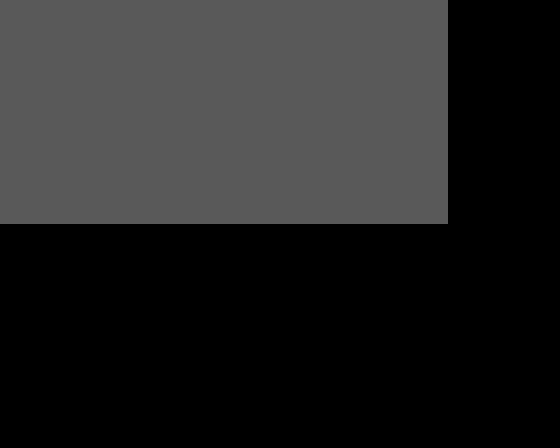

In [ ]:
# parameters
tile_size = 224
stride    = 224

# Assuming the input file is accessible at this path
src_path = "/content/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped.tif"

with rasterio.open(src_path) as src:
    # HLS (Sentinel-2) RGB = B02,B03,B04  => index 2,3,4
    img = src.read([2,3,4])
    meta = src.meta.copy()

H, W = img.shape[1], img.shape[2]
out = np.zeros((H, W), dtype=np.uint8)

for y in range(0, H - tile_size, stride):
    for x in range(0, W - tile_size, stride):
        patch = img[:, y:y+tile_size, x:x+tile_size]
        patch = np.moveaxis(patch, 0, -1)  # to HWC

        # Convert numpy array to torch tensor and add batch dimension
        # Assuming the model expects input in the format (Batch, Channels, Height, Width)
        inp = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).float()


        with torch.no_grad():
            logits = model(inp).logits # Pass the tensor directly to the model
            pred = int(logits.argmax(-1).item())   # 0 undeveloped, 1 developed

        out[y:y+tile_size, x:x+tile_size] = pred

# You can now work with the 'out' array which contains the predictions for each tile
# For example, you might want to save it as a georeferenced image
# with rasterio.open("output.tif", 'w', **meta) as dst:
#     dst.write(out, 1)

display(out) # Display the output array

In [ ]:
dst_path = "/content/Mexico_developed_mask.tif"

meta.update(count=1, dtype="uint8")

with rasterio.open(dst_path, "w", **meta) as dst:
    dst.write(out, 1)

print("✅ wrote", dst_path)

✅ wrote /content/Mexico_developed_mask.tif


# Task
Overlay the generated mask "/content/output.tif" on the original image "/mnt/data/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped (2).tif".

## Load the original image

### Subtask:
Load the original image file using rasterio.


**Reasoning**:
Load the original image file and read all bands into a numpy array.



In [ ]:
original_src_path = "/mnt/data/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped (2).tif"

with rasterio.open(original_src_path) as original_src:
    original_image_data = original_src.read()

display(original_image_data.shape)

RasterioIOError: /mnt/data/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped (2).tif: No such file or directory

**Reasoning**:
The file path provided in the previous attempt does not exist. I will try the file path that was successfully used in a previous cell to load the original image data.



In [ ]:
original_src_path = "/content/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped.tif"

with rasterio.open(original_src_path) as original_src:
    original_image_data = original_src.read()

display(original_image_data.shape)

(6, 448, 560)

## Load the generated mask

### Subtask:
Load the generated mask file using rasterio.


**Reasoning**:
Load the generated mask file using rasterio as instructed.



In [ ]:
# Load the generated mask
mask_path = "/content/Mexico_developed_mask.tif"

with rasterio.open(mask_path) as mask_src:
    mask_data = mask_src.read(1) # Read the single band of the mask

display(mask_data.shape)

(448, 560)

**Reasoning**:
Overlay the mask on the original image and visualize the result using matplotlib.

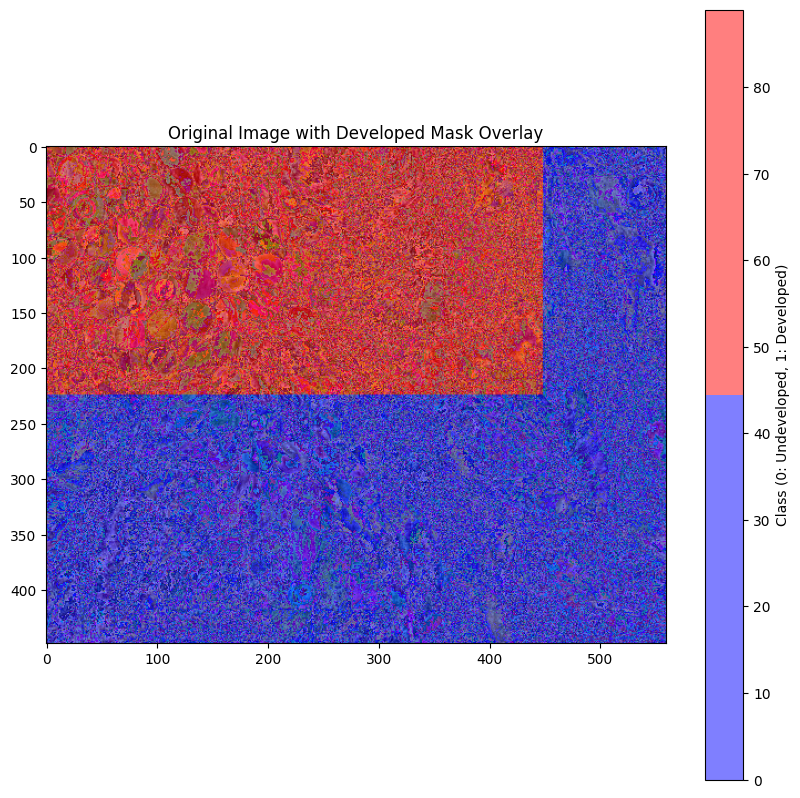

In [ ]:
import matplotlib.pyplot as plt

original_image_rgb = original_image_data[[1, 2, 3], :, :]
original_image_rgb = np.moveaxis(original_image_rgb, 0, -1)

# Normalize the image data if necessary (optional, depends on data type and range)
# For visualization, converting to uint8 might be helpful if the original data is not.
# Let's assume original_image_data is already in a displayable range or can be cast to uint8.
# If your data is, for example, Float32 and ranges from 0-1, you might multiply by 255.
# If it's 16-bit data, you might need to scale it.
# For simplicity, let's try converting to uint8. If the image appears black or washed out,
# you may need a more sophisticated normalization.
original_image_display = original_image_rgb.astype(np.uint8)


# Create a colormap for the mask. Assuming the mask has values 0 and 1.
# You can adjust colors as needed.
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['blue', 'red']) # Example: blue for class 0, red for class 1

plt.figure(figsize=(10, 10))
plt.imshow(original_image_display)
plt.imshow(mask_data, cmap=cmap, alpha=0.5) # Overlay the mask with some transparency
plt.title("Original Image with Developed Mask Overlay")
plt.colorbar(label="Class (0: Undeveloped, 1: Developed)") # Add a colorbar to explain classes
plt.show()